# Inception-Based Facial Emotion Recognition

## Project Overview
This notebook implements a deep learning model from scratch for facial emotion detection using a custom Inception architecture. 
The model is trained on the FERPlus dataset and optimized for Apple Silicon (M4) GPUs.

### Key Features:
- **Custom Inception Architecture**: Multi-scale feature extraction
- **Data Preprocessing**: Comprehensive cleaning, normalization and augmentation
- **Optimization**: Mixed precision training on Metal
- **Evaluation**: Extensive visualization and metrics

### Emotion Classes:
1. Angry
2. Contempt
3. Disgust
4. Fear
5. Happy
6. Neutral
7. Sad
8. Surprise

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import random
import datetime

# Set random seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configure GPU (Metal)
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))
if len(physical_devices) > 0:
    print("Using Metal acceleration on M-series chip")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# Create outputs directory
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/visualizations', exist_ok=True)
os.makedirs('outputs/logs', exist_ok=True)

print(f"TensorFlow Version: {tf.__version__}")

Num GPUs Available:  1
Using Metal acceleration on M-series chip
TensorFlow Version: 2.15.0


In [2]:
# Dataset Configuration
DATA_DIR = 'data/ferplus1'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'validation')
TEST_DIR = os.path.join(DATA_DIR, 'test')

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
NUM_CLASSES = 8
CLASSES = ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']

print("Classes:", CLASSES)

Classes: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']


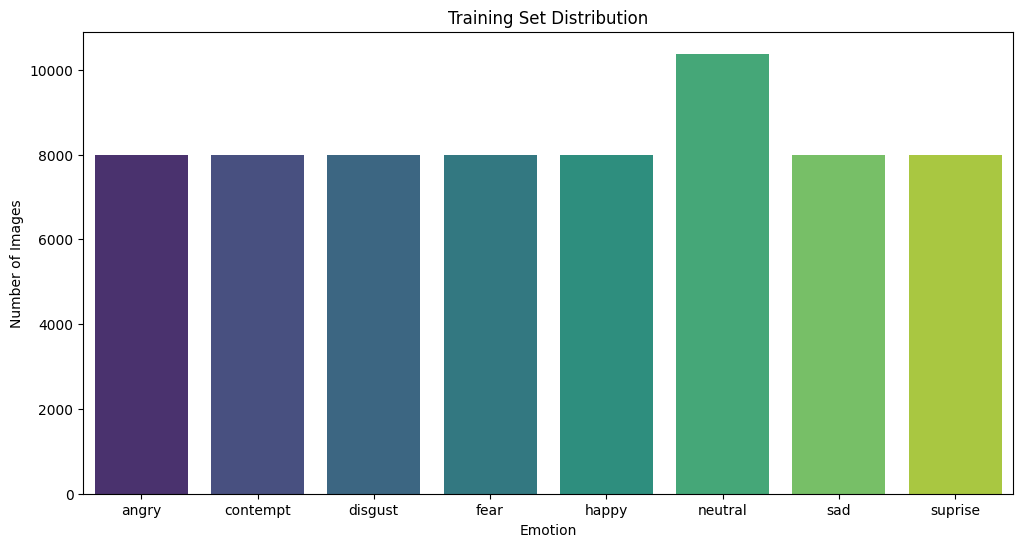

Training Counts: {'angry': 8000, 'contempt': 8000, 'disgust': 8000, 'fear': 8000, 'happy': 8000, 'neutral': 10379, 'sad': 8000, 'suprise': 8000}


In [3]:
def plot_class_distribution(directory, title='Class Distribution'):
    counts = {}
    for cls in CLASSES:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            counts[cls] = len(os.listdir(path))
        else:
            counts[cls] = 0
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')
    plt.title(title)
    plt.xlabel('Emotion')
    plt.ylabel('Number of Images')
    plt.show()
    return counts

train_counts = plot_class_distribution(TRAIN_DIR, 'Training Set Distribution')
print("Training Counts:", train_counts)

In [4]:
# Data Augmentation and Generators

# Training generator with AGGRESSIVE augmentation to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # Increased from 15
    zoom_range=0.2,         # Increased from 0.1
    shear_range=0.1,        # Added shear
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2], # Wider range
    fill_mode='nearest'
)

# Validation/Test generator (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 66379 images belonging to 8 classes.
Found 8341 images belonging to 8 classes.
Found 3573 images belonging to 8 classes.


## Custom Inception Architecture
We implement a custom Inception module with 4 parallel pathways:
1. 1x1 Conv
2. 1x1 Conv -> 3x3 Conv
3. 1x1 Conv -> 5x5 Conv
4. MaxPooling -> 1x1 Conv

In [5]:
def inception_module(x, filters):
    f1, f3_r, f3, f5_r, f5, proj = filters
    
    # 1x1 path
    path1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)
    path1 = layers.BatchNormalization()(path1)
    
    # 1x1 -> 3x3 path
    path2 = layers.Conv2D(f3_r, (1, 1), padding='same', activation='relu')(x)
    path2 = layers.BatchNormalization()(path2)
    path2 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(path2)
    path2 = layers.BatchNormalization()(path2)
    
    # 1x1 -> 5x5 path
    path3 = layers.Conv2D(f5_r, (1, 1), padding='same', activation='relu')(x)
    path3 = layers.BatchNormalization()(path3)
    path3 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(path3)
    path3 = layers.BatchNormalization()(path3)
    
    # Pooling path
    path4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    path4 = layers.Conv2D(proj, (1, 1), padding='same', activation='relu')(path4)
    path4 = layers.BatchNormalization()(path4)
    
    return layers.concatenate([path1, path2, path3, path4], axis=-1)

def build_inception_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Initial Stem
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    x = layers.Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    # Inception Blocks
    # Format: [f1, f3_r, f3, f5_r, f5, proj]
    x = inception_module(x, [64, 96, 128, 16, 32, 32])
    x = inception_module(x, [128, 128, 192, 32, 96, 64])
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    x = inception_module(x, [192, 96, 208, 16, 48, 64])
    
    # Classification Head (STRONGER REGULARIZATION)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x) # L2 0.001 -> 0.005
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x) # Dropout 0.5 -> 0.6
    
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x) # L2 0.001 -> 0.005
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x) # Dropout 0.4 -> 0.5
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name='Inception_FER')

model = build_inception_model(input_shape=(48, 48, 1), num_classes=NUM_CLASSES)
model.summary()

2025-12-27 19:45:22.054994: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-12-27 19:45:22.055031: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-27 19:45:22.055039: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-27 19:45:22.055088: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-27 19:45:22.055114: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Inception_FER"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 24, 24, 64)           3200      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 24, 24, 64)           256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)           0         ['batch_normalizat

In [6]:
# Compilation and Callbacks
optimizer = optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_acc')]
)

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,         # Reduced from 15 to stop overfitting sooner
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,          # Reduced from 5 to react faster
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'outputs/models/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks_list,
    class_weight=None  # Can add class weights if needed
)

Epoch 1/20


2025-12-27 19:45:24.319370: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-27 19:45:24.560759: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


1038/1038 [==============================] - ETA: 0s - loss: 3.0497 - accuracy: 0.2231 - top_2_acc: 0.4014
Epoch 1: val_accuracy improved from -inf to 0.26436, saving model to outputs/models/best_model.keras
1038/1038 [==============================] - 42s 38ms/step - loss: 3.0497 - accuracy: 0.2231 - top_2_acc: 0.4014 - val_loss: 2.0623 - val_accuracy: 0.2644 - val_top_2_acc: 0.4440 - lr: 0.0010
Epoch 2/20
1037/1038 [============================>.] - ETA: 0s - loss: 1.8865 - accuracy: 0.3664 - top_2_acc: 0.5726
Epoch 2: val_accuracy improved from 0.26436 to 0.37957, saving model to outputs/models/best_model.keras
1038/1038 [==============================] - 39s 38ms/step - loss: 1.8864 - accuracy: 0.3665 - top_2_acc: 0.5726 - val_loss: 1.8247 - val_accuracy: 0.3796 - val_top_2_acc: 0.5811 - lr: 0.0010
Epoch 3/20
1038/1038 [==============================] - ETA: 0s - loss: 1.6657 - accuracy: 0.4717 - top_2_acc: 0.6770
Epoch 3: val_accuracy improved from 0.37957 to 0.43532, saving model

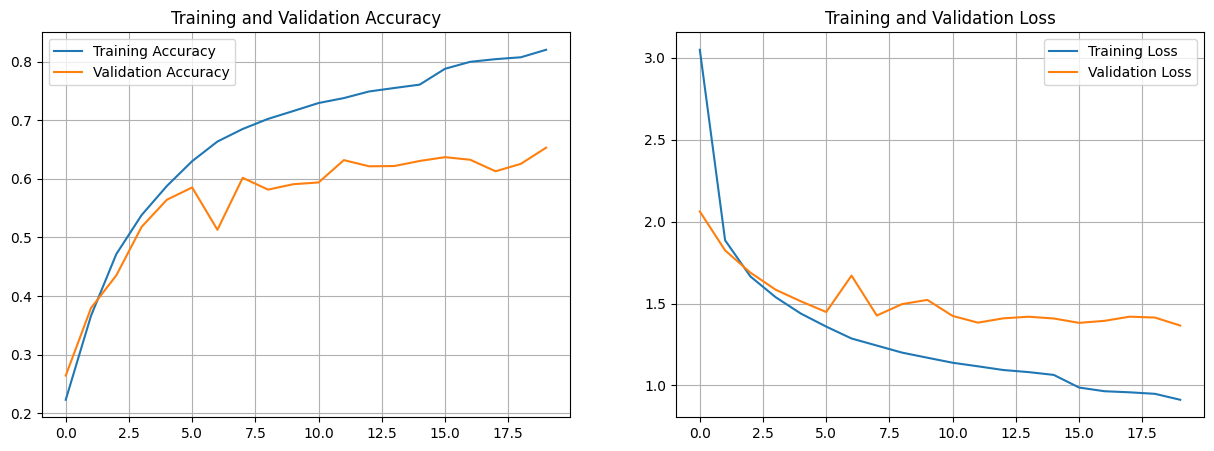

<Figure size 640x480 with 0 Axes>

In [11]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    plt.figure(figsize=(15, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()
    plt.savefig('outputs/visualizations/training_history.png')

plot_training_history(history)

56/56 [==============================] - 1s 22ms/step - loss: 1.0945 - accuracy: 0.7221 - top_2_acc: 0.8959
Test Accuracy: 0.7221
Test Top-2 Accuracy: 0.8959
56/56 [==============================] - 1s 16ms/step


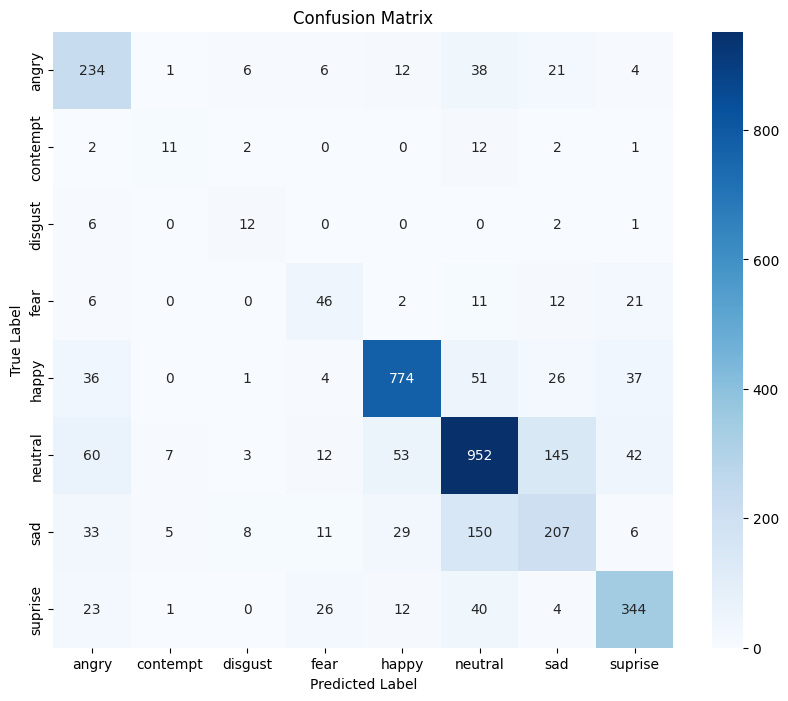

              precision    recall  f1-score   support

       angry       0.58      0.73      0.65       322
    contempt       0.44      0.37      0.40        30
     disgust       0.38      0.57      0.45        21
        fear       0.44      0.47      0.45        98
       happy       0.88      0.83      0.85       929
     neutral       0.76      0.75      0.75      1274
         sad       0.49      0.46      0.48       449
     suprise       0.75      0.76      0.76       450

    accuracy                           0.72      3573
   macro avg       0.59      0.62      0.60      3573
weighted avg       0.73      0.72      0.72      3573



In [8]:
# Evaluation on Test Set
test_loss, test_acc, test_top2 = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Top-2 Accuracy: {test_top2:.4f}")

# Generate Predictions
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('outputs/visualizations/confusion_matrix.png')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=CLASSES))

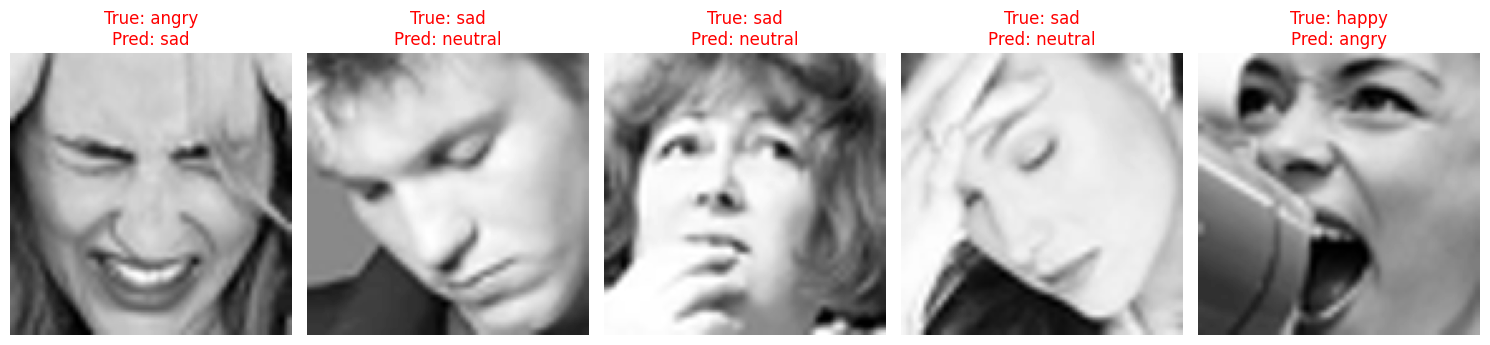

In [9]:
def plot_misclassified_images(generator, y_true, y_pred, num_images=5):
    misclassified_indices = np.where(y_true != y_pred)[0]
    if len(misclassified_indices) == 0:
        print("No misclassified images found!")
        return
    
    selected_indices = np.random.choice(misclassified_indices, num_images, replace=False)
    
    # We need to get the filepaths from the generator
    filepaths = generator.filepaths
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(selected_indices):
        img_path = filepaths[idx]
        img = plt.imread(img_path)
        
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {CLASSES[y_true[idx]]}\nPred: {CLASSES[y_pred[idx]]}", color='red')
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/visualizations/misclassified_samples.png')
    plt.show()

plot_misclassified_images(test_generator, y_true, y_pred)

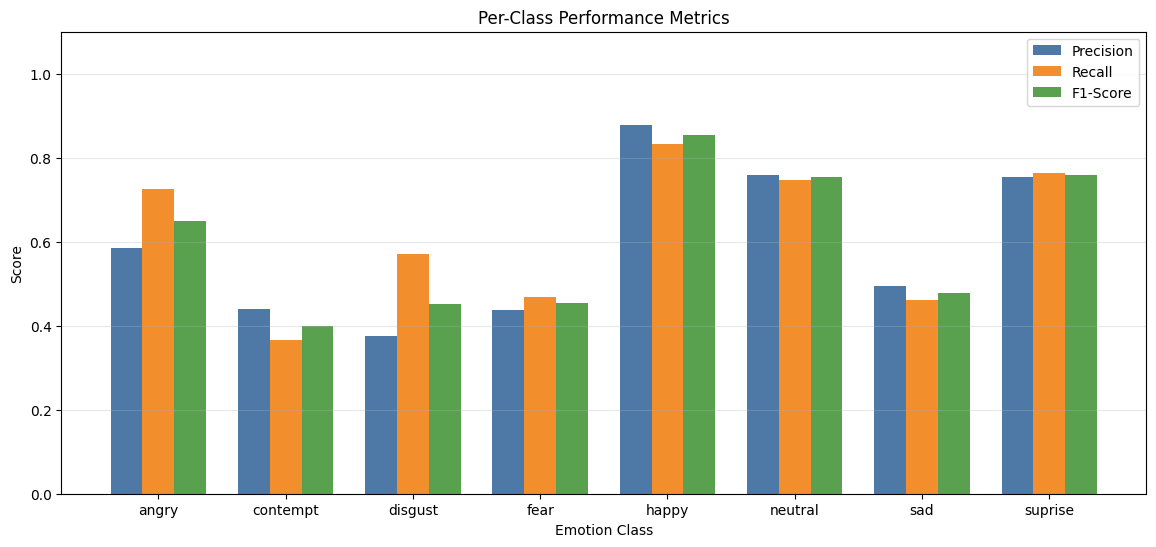

56/56 [==============================] - 1s 19ms/step


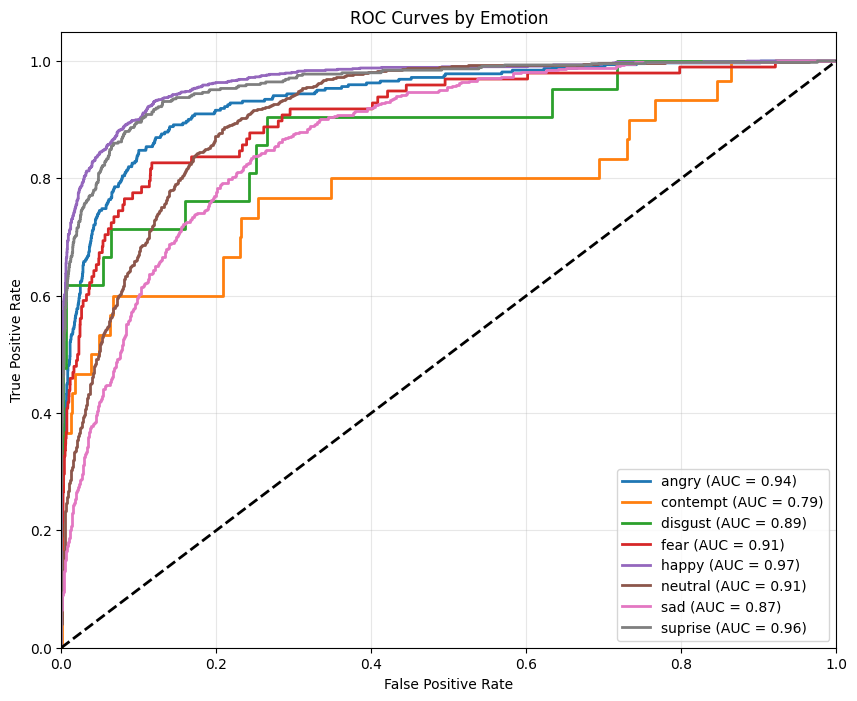

In [13]:
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# 1. Per-Class Performance Bar Chart
def plot_per_class_metrics(y_true, y_pred, classes):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    x = np.arange(len(classes))
    width = 0.25
    
    plt.figure(figsize=(14, 6))
    plt.bar(x - width, precision, width, label='Precision', color='#4e79a7')
    plt.bar(x, recall, width, label='Recall', color='#f28e2b')
    plt.bar(x + width, f1, width, label='F1-Score', color='#59a14f')
    
    plt.xlabel('Emotion Class')
    plt.ylabel('Score')
    plt.title('Per-Class Performance Metrics')
    plt.xticks(x, classes)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('outputs/visualizations/per_class_metrics.png')
    plt.show()

# 2. ROC Curves for Each Class
def plot_multiclass_roc(model, generator, classes):
    # Get raw probabilities
    y_score = model.predict(generator)
    y_test_bin = label_binarize(generator.classes, classes=range(len(classes)))
    
    plt.figure(figsize=(10, 8))
    
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves by Emotion')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('outputs/visualizations/roc_curves.png')
    plt.show()



# Execute visuals
plot_per_class_metrics(y_true, y_pred, CLASSES)
plot_multiclass_roc(model, test_generator, CLASSES)
